In [1]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)


In [2]:
import sys
import os
sys.path.append(os.path.abspath("/Users/imanemokhtatif/Desktop/REMOTEChlamy_Project_v2-main"))
#sys.path.append(os.path.abspath("/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main"))

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import euclidean_distances
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np


In [6]:
old = pd.read_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/2025_5_phase1_light_status_slope_randeffONLYPLATES_ontimepoints.csv')
new = pd.read_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/2025_5_phase2_light_status_slope.csv')

# new = old[old['plate'].astype(str).str.endswith('v2')]
# old = old[old['plate'].astype(str).str.endswith('v1')]

/tmp/ipykernel_854135/519644604.py:1: DtypeWarning: Columns (299,300,301,302,303,304,305,306,307,308,309,310,311,312,313,314,315,316,317,318,319,320,321,322,323,324,325,326,327,328,329,330,331,332,333,334,335,336,337,338,342,389,390,391,392,393,394,395,396,397,398,399,400,401,402,403,404,405,406,407,408,409,410,411,412,413,414,415,416,417,418,419,420,421,422,423,424,425,426,427,428) have mixed types. Specify dtype option on import or set low_memory=False.
  old = pd.read_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/2025_5_phase1_light_status_slope_randeffONLYPLATES_ontimepoints.csv')


In [11]:
old['y2_slope'] = old['z_score']
new['y2_slope'] = new['z_score']

## Linear regression Correlation and trajectories

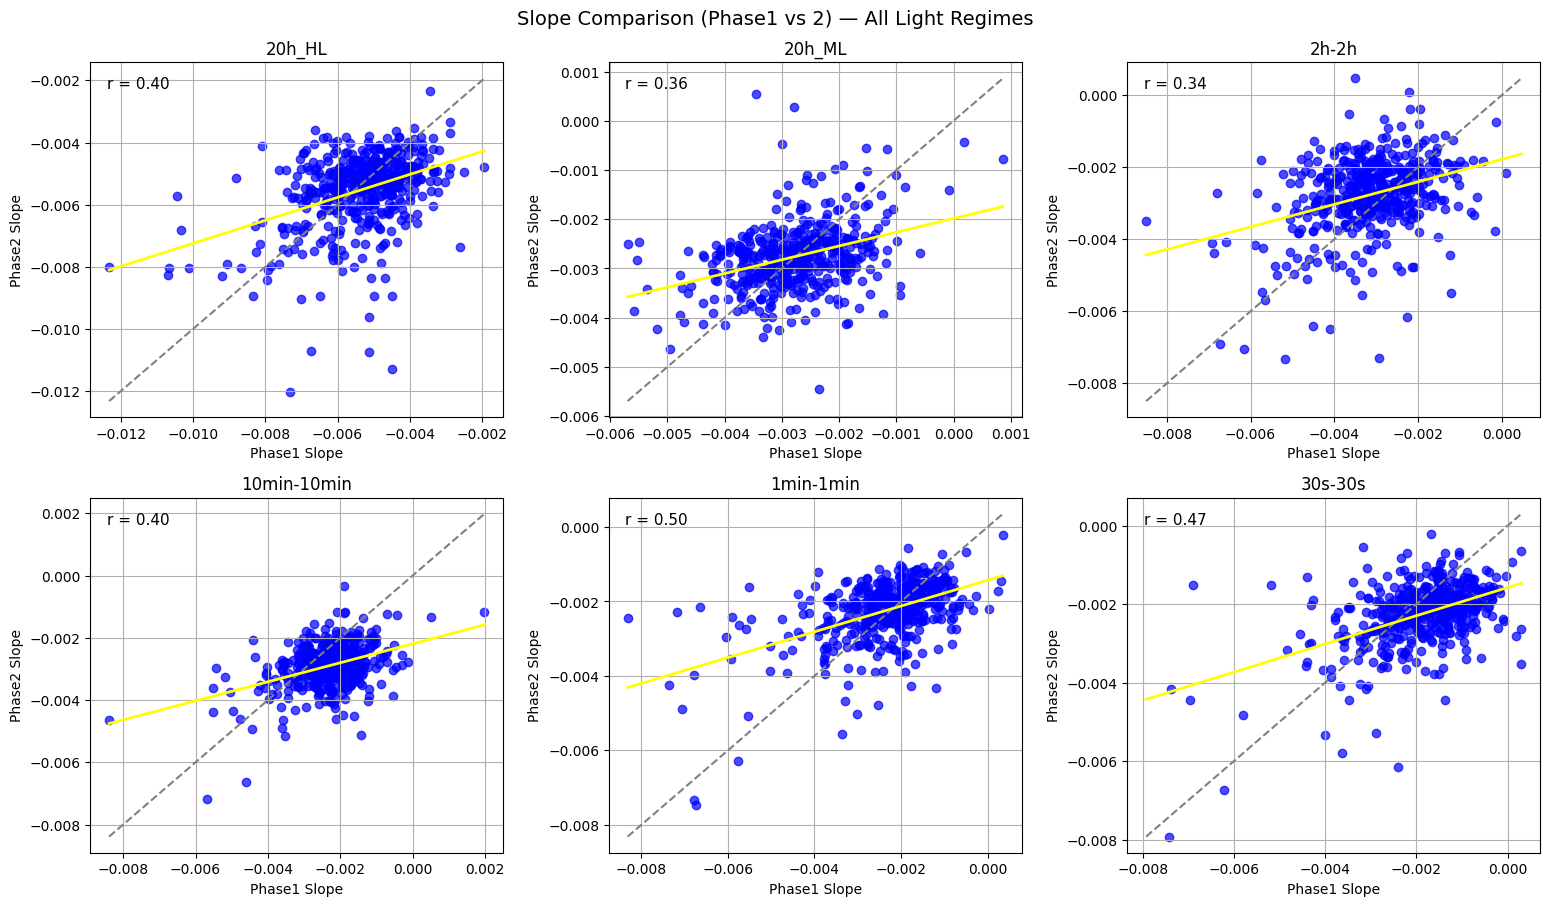

Number of changing genes:  0
Empty DataFrame
Columns: [mutated_genes, light_regime]
Index: []


In [ ]:
threshold = 2
light_regimes = ['20h_HL', '20h_ML', '2h-2h', '10min-10min', '1min-1min', '30s-30s']

import math
n = len(light_regimes)
ncols = min(3, n)                      
nrows = math.ceil(n / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(5.2*ncols, 4.6*nrows))
axes = np.atleast_1d(axes).reshape(nrows, ncols)

all_sig = []  

for idx, light in enumerate(light_regimes):
    r, c = divmod(idx, ncols)
    ax = axes[r, c]

    old_light = old[old['light_regime'] == light]
    new_light = new[new['light_regime'] == light]

    old_avg = old_light.groupby('mutated_genes')['y2_slope'].mean().reset_index(name='old_slope')
    new_avg = new_light.groupby('mutated_genes')['y2_slope'].mean().reset_index(name='new_slope')

    merged = pd.merge(old_avg, new_avg, on='mutated_genes', how='inner')
    merged['abs_diff'] = np.abs(merged['old_slope'] - merged['new_slope'])
    merged['significant'] = (merged['abs_diff'] > threshold)

    corr = merged[['old_slope', 'new_slope']].corr().iloc[0, 1]

    for _, row in merged.iterrows():
        color = 'red' if row['significant'] else 'blue'
        ax.scatter(row['old_slope'], row['new_slope'], color=color, alpha=0.7)

    min_val = min(merged['old_slope'].min(), merged['new_slope'].min())
    max_val = max(merged['old_slope'].max(), merged['new_slope'].max())
    ax.plot([min_val, max_val], [min_val, max_val], color='gray', linestyle='--')

    if len(merged) >= 2 and np.isfinite(merged[['old_slope', 'new_slope']].values).all():
        m, b = np.polyfit(merged['old_slope'].values, merged['new_slope'].values, 1)
        xs = np.array([min_val, max_val])
        ax.plot(xs, m*xs + b, color='yellow', linewidth=2, label='OLS fit')

    ax.set_xlabel('Phase1 Slope')
    ax.set_ylabel('Phase2 Slope')
    ax.set_title(f'{light}')
    ax.grid(True)
    ax.text(0.04, 0.96, f"r = {corr:.2f}", transform=ax.transAxes,
            fontsize=11, va='top')

    merged['light_regime'] = light
    significant_mutants = merged[merged['significant']]
    sig = significant_mutants[['mutated_genes', 'light_regime']].drop_duplicates()
    all_sig.append(sig)

for j in range(idx+1, nrows*ncols):
    r, c = divmod(j, ncols)
    fig.delaxes(axes[r, c])

plt.suptitle('Slope Comparison (Phase1 vs 2) — All Light Regimes', fontsize=14)
plt.tight_layout()
plt.show()

if all_sig:
    sig_df = pd.concat(all_sig, ignore_index=True)
    print('Number of changing genes: ', len(sig_df))
    print(sig_df)
else:
    print('Number of changing genes: 0')


## Intra-distance

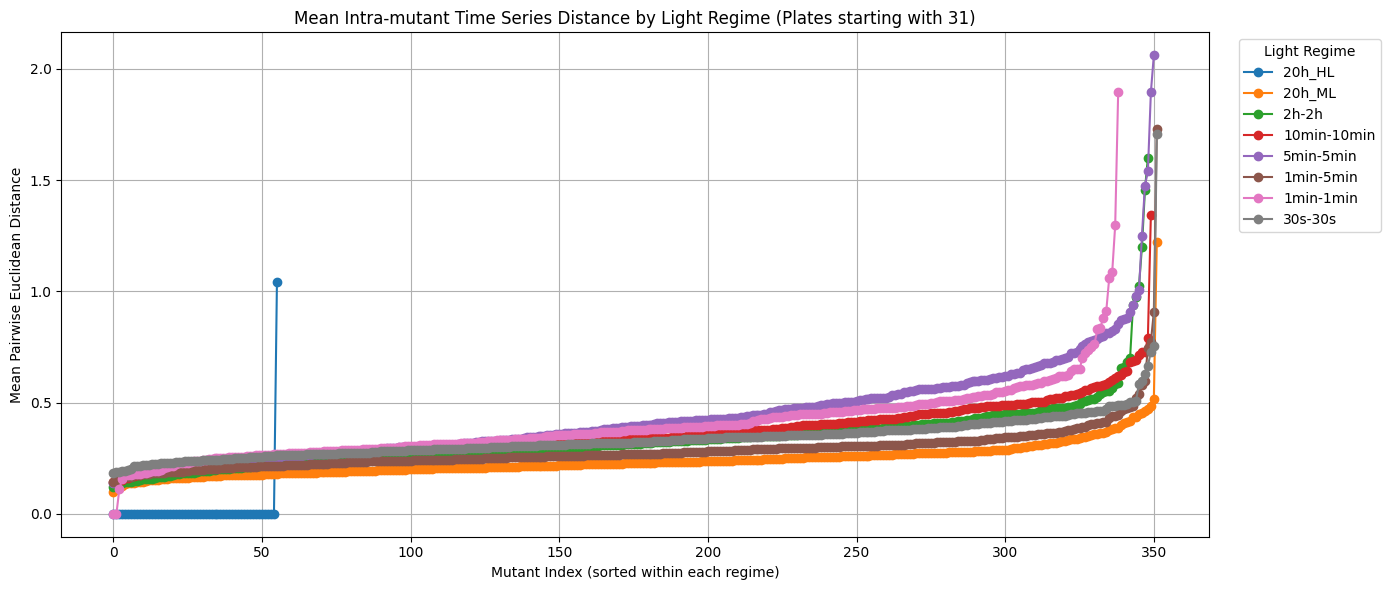

Total entries: 2501
               mean    max    std
light_regime                     
10min-10min   0.363  1.342  0.126
1min-1min     0.396  1.895  0.172
1min-5min     0.287  1.732  0.114
20h_HL        0.019  1.041  0.139
20h_ML        0.240  1.223  0.083
2h-2h         0.336  1.602  0.157
30s-30s       0.338  1.707  0.109
5min-5min     0.438  2.062  0.227

Top outliers in 20h_HL:
             mutant_ID  mean_distance  n_replicas
55                 WT   1.041154e+00           7
12  LMJ.RY0402.085477   7.450581e-09           3
37  LMJ.RY0402.174133   7.450581e-09           2
43  LMJ.RY0402.197381   7.450581e-09           2
32  LMJ.RY0402.158731   7.450581e-09           2

Top outliers in 20h_ML:
              mutant_ID  mean_distance  n_replicas
407                 WT       1.223173          21
139  LMJ.RY0402.092899       0.514721           2
93   LMJ.RY0402.061747       0.485852           3
172  LMJ.RY0402.116119       0.470322           3
326  LMJ.RY0402.206387       0.461761       

In [ ]:
plate_num = '31'
subset = data[data['plate'].astype(str).str.startswith(plate_num)]
y2_cols = [col for col in data.columns if (col.startswith('y2_')) and ('std' not in col)]
light_regimes = ['20h_HL', '20h_ML', '2h-2h', '10min-10min', '5min-5min', '1min-5min', '1min-1min', '30s-30s']

all_stats = []

for light in light_regimes:
    sub_light = subset[subset['light_regime'] == light]

    for mutant_id, group in sub_light.groupby('mutant_ID'):
        ts = group[y2_cols]

        min_valid_ratio = 0.9
        valid_counts = ts.notna().mean()  # proportion of non-NaNs per column
        valid_cols = valid_counts[valid_counts >= min_valid_ratio].index
        ts = ts[valid_cols].dropna()

        if ts.shape[0] < 2 or ts.shape[1] == 0:
            continue  # Need at least 2 series to compute pairwise distances

        D = euclidean_distances(ts.values)
        triu_vals = D[np.triu_indices_from(D, k=1)]
        all_stats.append({
            'mutant_ID': mutant_id,
            'light_regime': light,
            'mean_distance': np.mean(triu_vals),
            'std_distance': np.std(triu_vals),
            'n_replicas': ts.shape[0]
        })

df_stats = pd.DataFrame(all_stats)

plt.figure(figsize=(14, 6))

for light in light_regimes:
    df_light = df_stats[df_stats['light_regime'] == light].sort_values('mean_distance')
    plt.plot(
        range(len(df_light)),
        df_light['mean_distance'].values,
        marker='o',
        linestyle='-',
        label=light
    )

plt.title(f"Mean Intra-mutant Time Series Distance by Light Regime (Plates starting with {plate_num})")
plt.xlabel("Mutant Index (sorted within each regime)")
plt.ylabel("Mean Pairwise Euclidean Distance")
plt.legend(title="Light Regime", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"Total entries: {len(df_stats)}")
print(df_stats.groupby('light_regime')['mean_distance'].agg(['mean', 'max', 'std']).round(3))

for light in light_regimes:
    outliers = df_stats[df_stats['light_regime'] == light].sort_values('mean_distance', ascending=False).head(5)
    print(f"\nTop outliers in {light}:\n", outliers[['mutant_ID', 'mean_distance', 'n_replicas']])


## Scatter plots of y2_slope values for the three replicas (1 phase1), for each mutant, per plate & light regime

/var/folders/_k/7_jrlrl97z33vpfdszcnhl780000gn/T/ipykernel_7759/531475299.py:5: DtypeWarning: Columns (462,463) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv('/Users/imanemokhtatif/Desktop/REMOTEChlamy_Project_v2-main/Data/phase2_05_RAWslopes.csv')


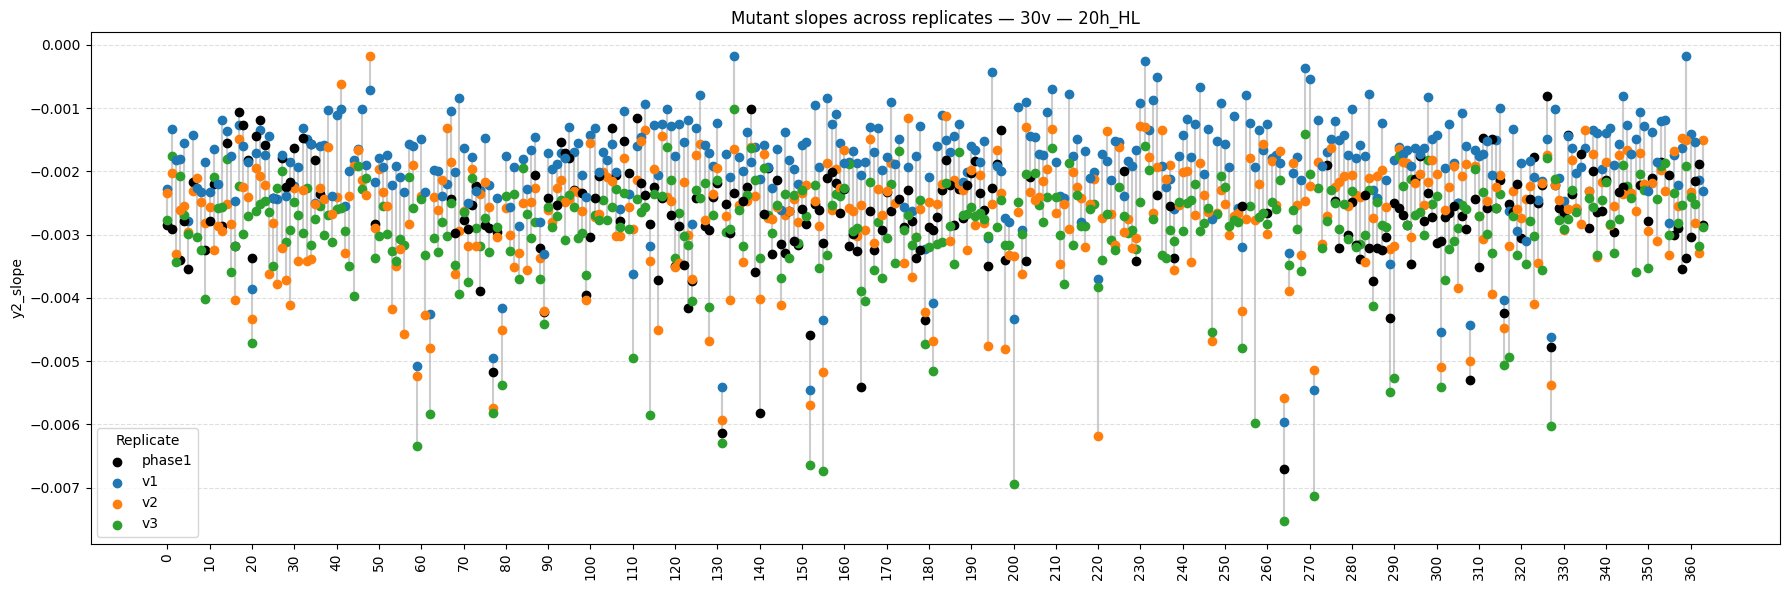

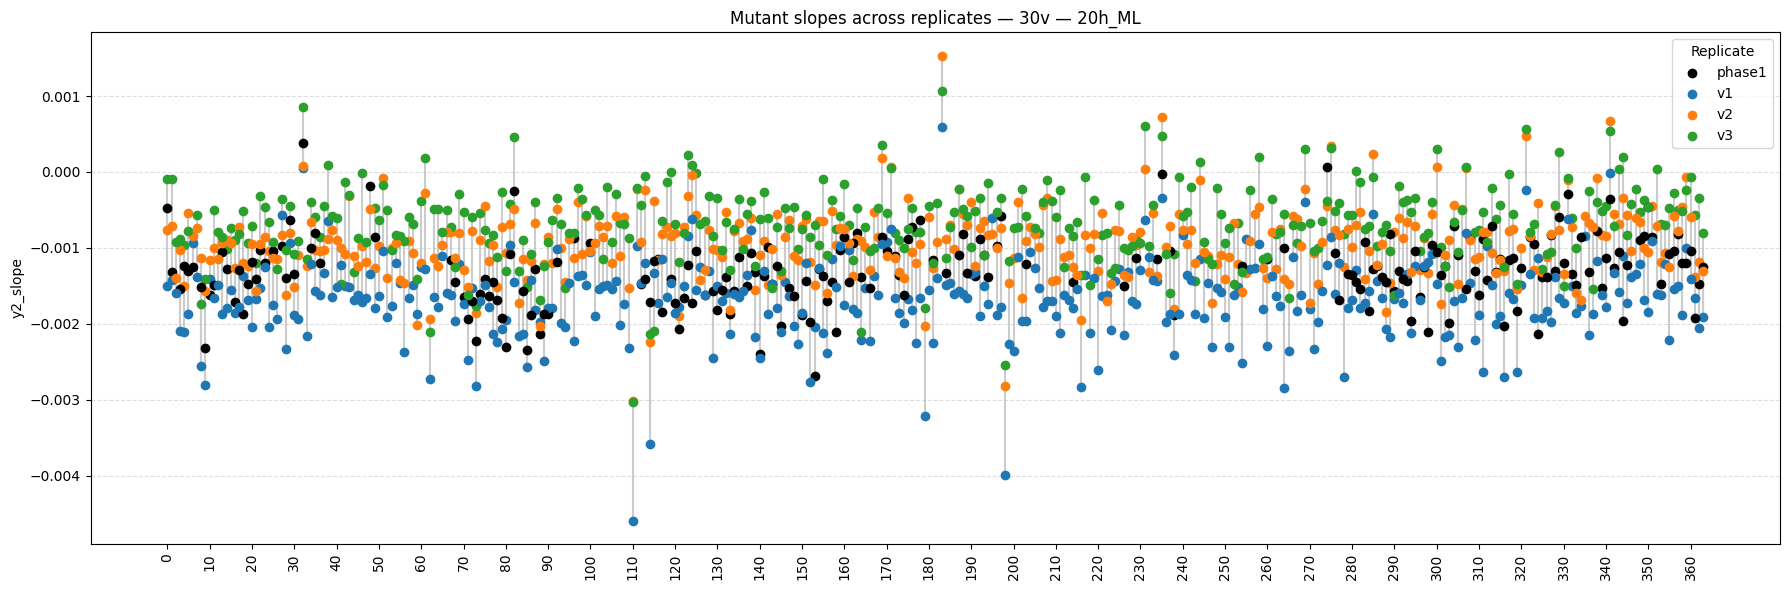

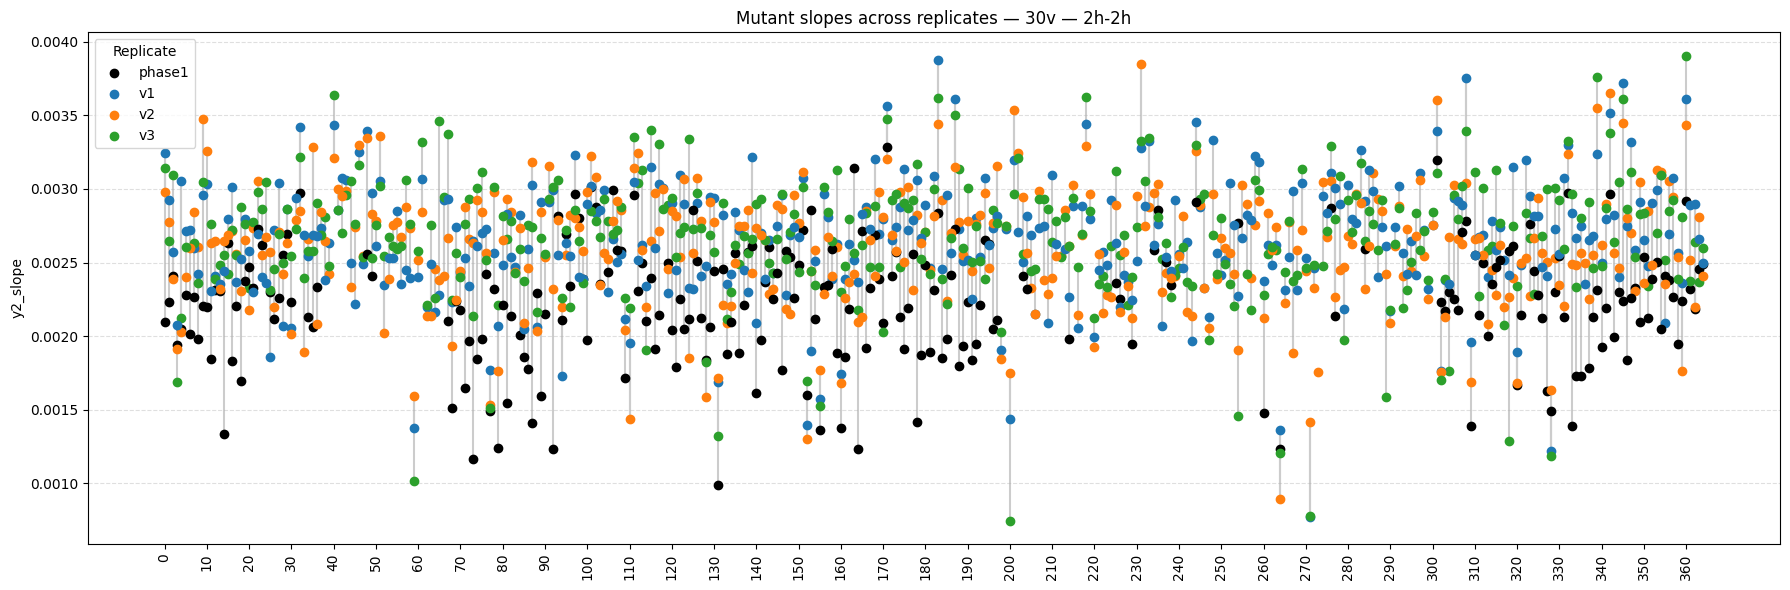

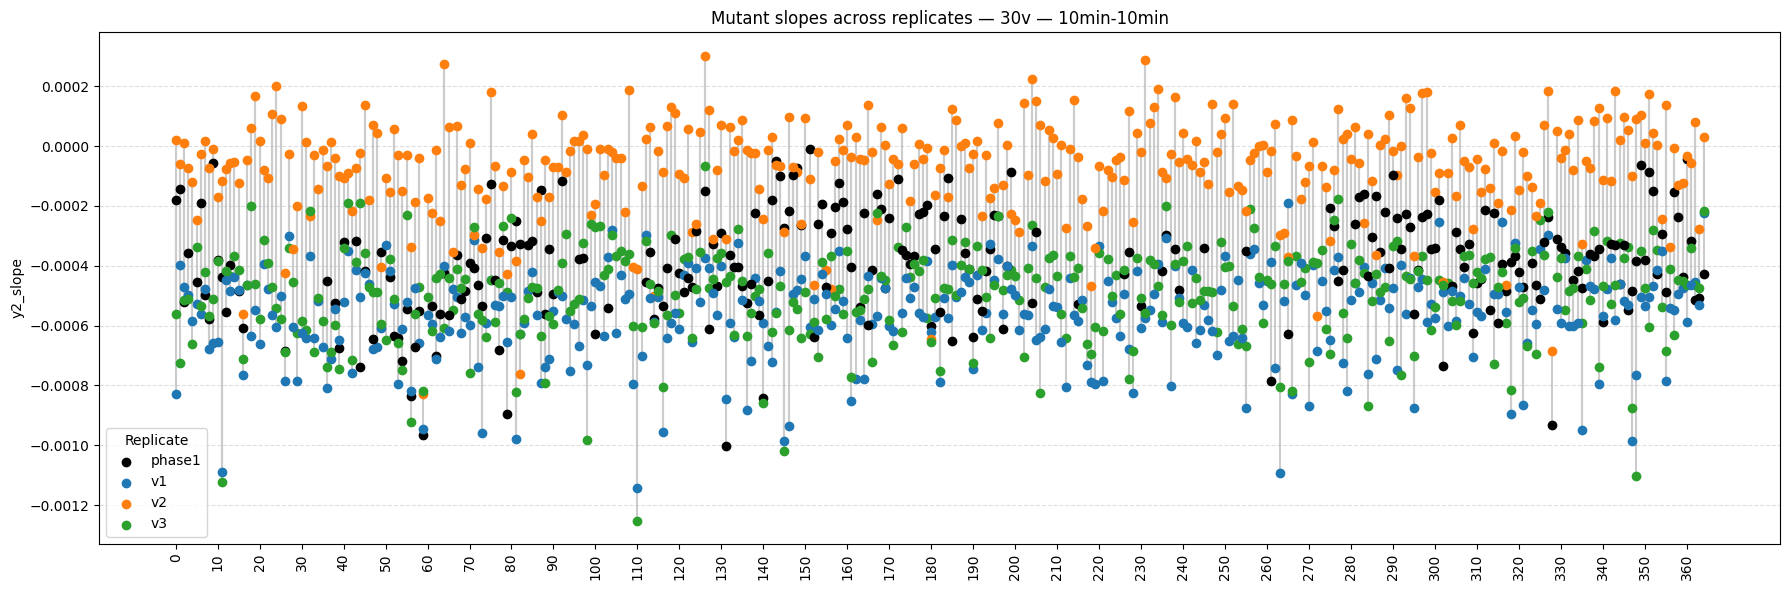

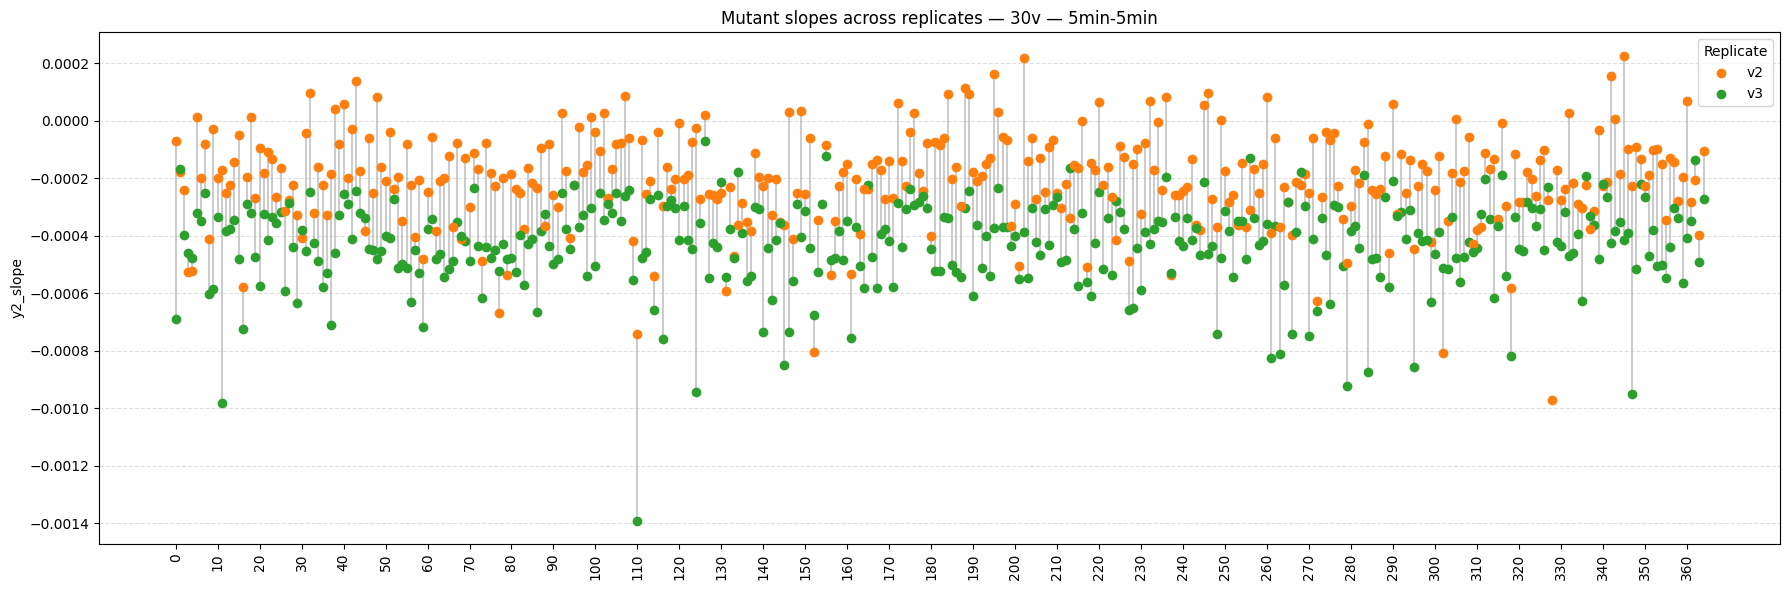

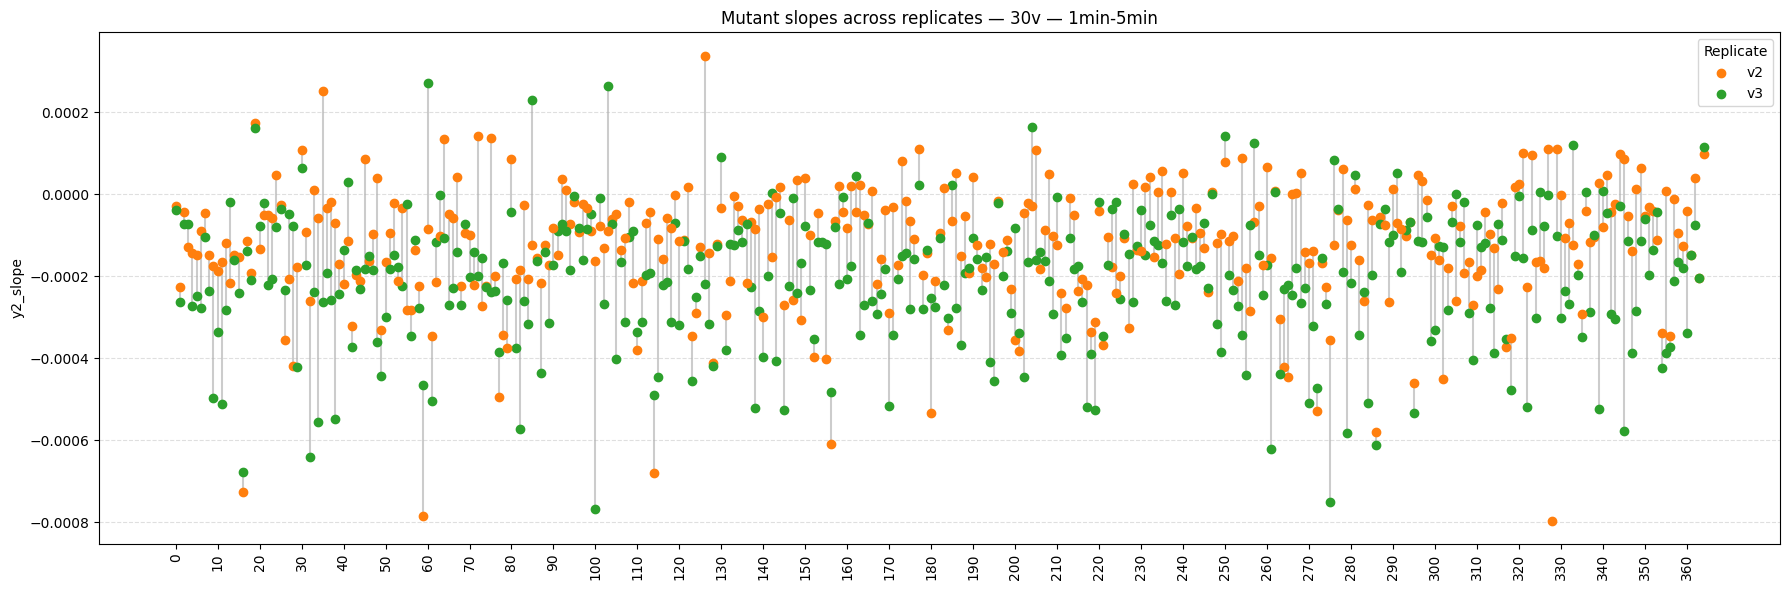

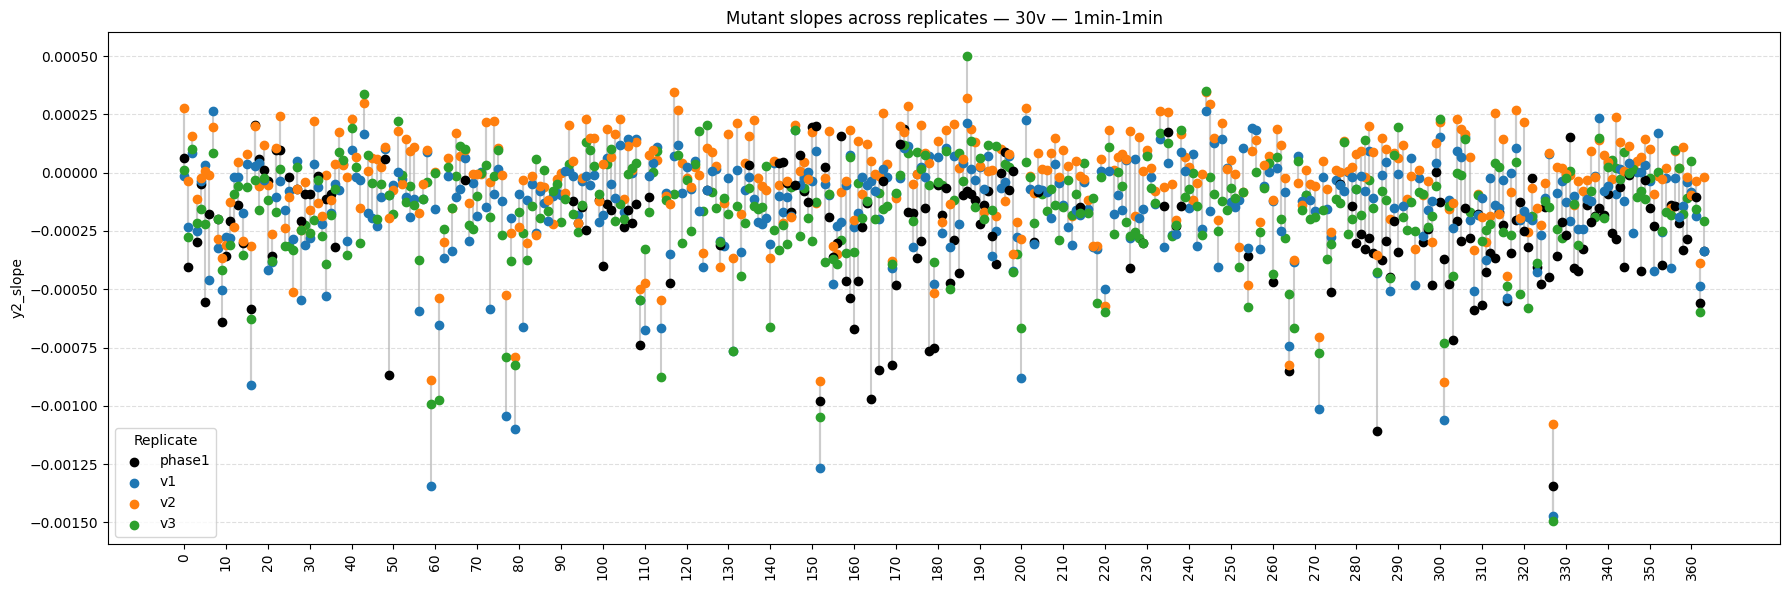

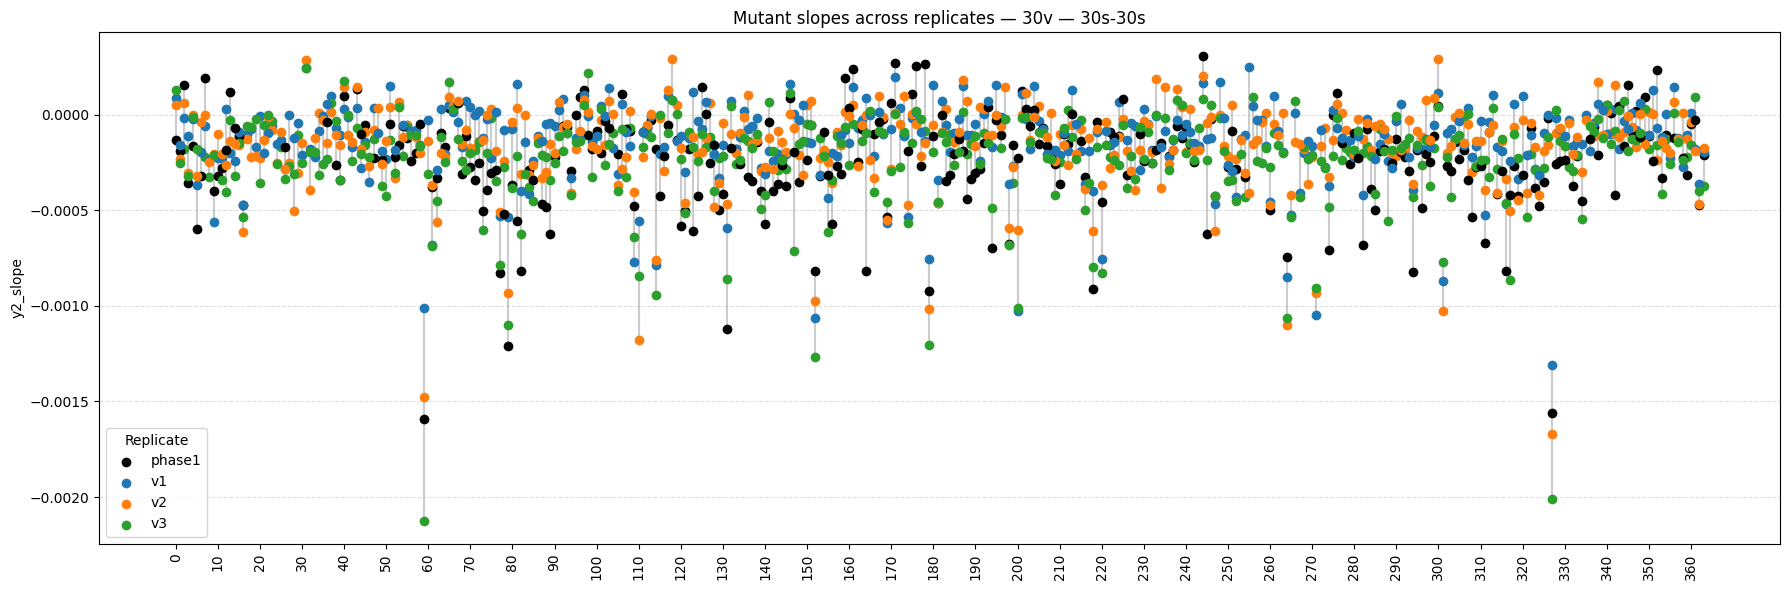

In [ ]:
data = pd.read_csv('/Users/imanemokhtatif/Desktop/REMOTEChlamy_Project_v2-main/Data/phase2_05_RAWslopes.csv')
phase1_data = pd.read_csv('/Users/imanemokhtatif/Desktop/REMOTEChlamy_Project_v2-main/Data/phase1_05_RAWslopes.csv')

lights = ['20h_HL', '20h_ML', '2h-2h', '10min-10min', '5min-5min', '1min-5min', '1min-1min', '30s-30s']
palette = {'v1': 'tab:blue', 'v2': 'tab:orange', 'v3': 'tab:green', 'phase1': 'black'}

for light in lights:
    plate_group = '30v'

    subset = data[
        (data['light_regime'] == light) &
        (~data['mutant_ID'].isin(['WT', 'WT CLiP'])) &
        (data['plate'].astype(str).str.startswith(plate_group))
    ].copy()
    subset['rep'] = subset['plate'].astype(str).str.extract(r'v(\d)').astype(int)
    subset['rep'] = subset['rep'].map({1: 'v1', 2: 'v2', 3: 'v3'})
    subset['mutant_ID'] = subset['mutant_ID'].astype(str)

    # Add phase1 data
    old_subset = phase1_data[
        (phase1_data['light_regime'] == light) &
        (~data['mutant_ID'].isin(['WT', 'WT CLiP'])) &
        (phase1_data['mutant_ID'].isin(subset['mutant_ID'].unique()))
    ][['mutant_ID', 'y2_slope']].copy()
    old_subset['rep'] = 'phase1'

    subset = pd.concat([subset[['mutant_ID', 'y2_slope', 'rep']], old_subset], ignore_index=True)
    subset['mutant_ID'] = subset['mutant_ID'].astype(str)

    mutant_order = sorted(subset['mutant_ID'].unique())
    subset['mutant_index'] = subset['mutant_ID'].apply(lambda x: mutant_order.index(x))

    plt.figure(figsize=(18, 6))

    for mutant in subset['mutant_ID'].unique():
        m_data = subset[subset['mutant_ID'] == mutant].sort_values('rep')
        x = mutant_order.index(mutant)
        y_vals = m_data['y2_slope'].values
        reps = m_data['rep'].values

        if len(y_vals) > 1:
            plt.plot([x]*len(y_vals), y_vals, color='gray', alpha=0.4, zorder=1)

        for rep, y in zip(reps, y_vals):
            plt.scatter(x, y, color=palette.get(rep, 'black'), label=rep if x == 0 else "", zorder=2)
    plt.xticks(range(0, len(mutant_order), 10), range(0, len(mutant_order), 10), rotation=90)
    plt.ylabel("y2_slope")
    plt.title(f"Mutant slopes across replicates — {plate_group} — {light}")
    plt.legend(title="Replicate")
    plt.grid(True, axis='y', linestyle='--', alpha=0.4)
    plt.tight_layout()
    plt.show()


### Another visualisation : heatmap

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

pivot = (
    subset
    .groupby(['mutant_ID', 'rep'])['y2_slope']
    .mean()
    .unstack()
)
n_mutants = pivot.shape[0]
height_per_mutant = 0.25  
fig_height = n_mutants * height_per_mutant

plt.figure(figsize=(6, fig_height))
sns.heatmap(pivot, cmap='vlag', center=0, cbar=True)

plt.title(f"Slope heatmap — {plate_group} — {light}")
plt.xlabel("Replicate")
plt.ylabel("Mutant")
plt.tight_layout()
plt.show()


#### Average standard deviation per light regime withing the different plate groups

   light_regime plate_group   avg_std
0        20h_HL         30v  0.000649
1        20h_HL         31v  0.000335
2        20h_HL         32v  0.000411
3        20h_HL         33v  0.000501
4        20h_ML         30v  0.000540
5        20h_ML         31v  0.000368
6        20h_ML         32v  0.000264
7        20h_ML         33v  0.000372
8         2h-2h         30v  0.000202
9         2h-2h         31v  0.000301
10        2h-2h         32v  0.000293
11        2h-2h         33v  0.000274
12  10min-10min         30v  0.000275
13  10min-10min         31v  0.000144
14  10min-10min         32v  0.000164
15  10min-10min         33v  0.000084
16    5min-5min         30v  0.000169
17    5min-5min         31v  0.000159
18    5min-5min         32v  0.000113
19    5min-5min         33v  0.000085
20    1min-5min         30v  0.000103
21    1min-5min         31v  0.000079
22    1min-5min         32v  0.000085
23    1min-5min         33v  0.000102
24    1min-1min         30v  0.000109
25    1min-1

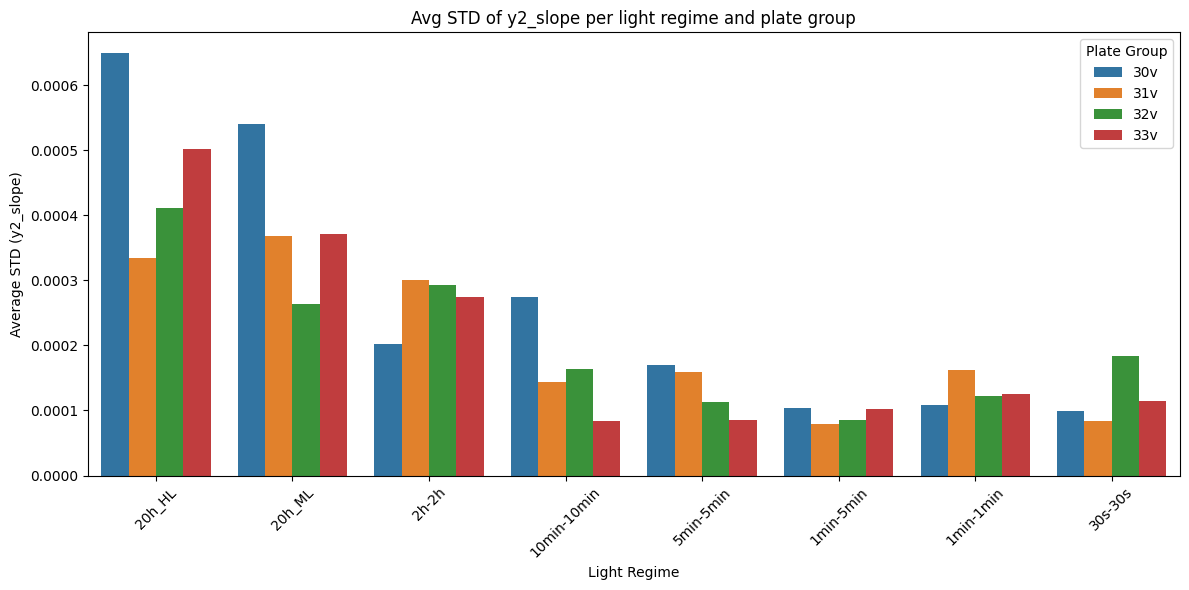

In [20]:
plate_groups = ['30v', '31v', '32v', '33v']
results = []

for light in lights:
    for plate_group in plate_groups:
        subset = data[
            (data['light_regime'] == light) &
            (~data['mutant_ID'].isin(['WT', 'WT CLiP'])) &
            (data['plate'].astype(str).str.startswith(plate_group))
        ].copy()
        subset['mutant_ID'] = subset['mutant_ID'].astype(str)
        subset['rep'] = subset['plate'].astype(str).str.extract(r'v(\d)').astype(int)

        if len(subset) == 0:
            continue

        # Group by mutant and compute std
        std_per_mutant = subset.groupby('mutant_ID')['y2_slope'].std()

        # Drop NaNs (e.g., mutants with only one replicate)
        avg_std = std_per_mutant.dropna().mean()

        results.append({'light_regime': light, 'plate_group': plate_group, 'avg_std': avg_std})

# To view the result:
result_df = pd.DataFrame(results)
print(result_df)
plt.figure(figsize=(12, 6))
sns.barplot(data=result_df, x='light_regime', y='avg_std', hue='plate_group')
plt.title("Avg STD of y2_slope per light regime and plate group")
plt.ylabel("Average STD (y2_slope)")
plt.xlabel("Light Regime")
plt.xticks(rotation=45)
plt.legend(title="Plate Group")
plt.tight_layout()
plt.show()


### ICC(2,1) analysis

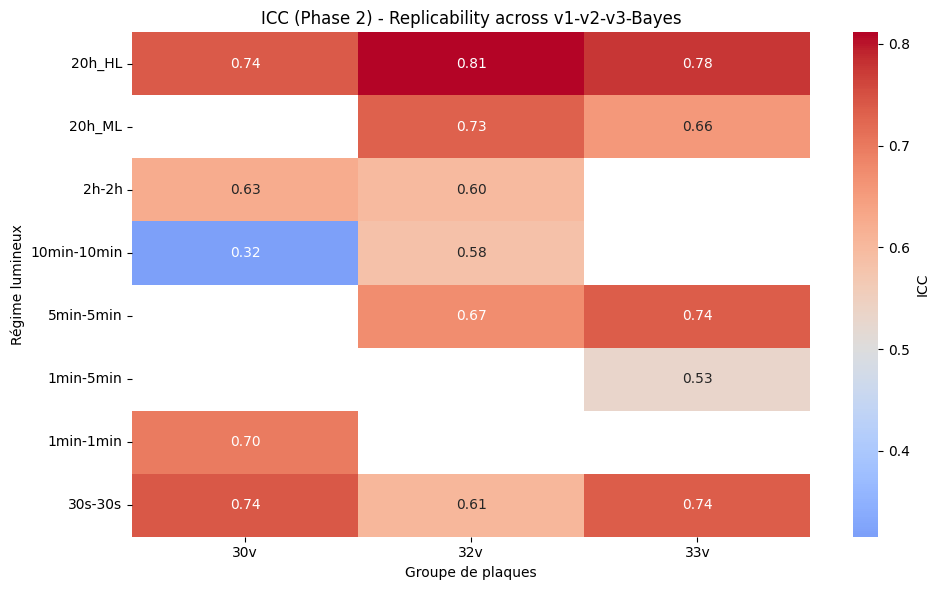

In [ ]:

# Charger les données
data = pd.read_csv('/Users/imanemokhtatif/Desktop/REMOTEChlamy_Project_v2-main/Data/2025_5_phase2_light_status_slope_COMBATT_randeffONLYPLATES.csv')
lights = ['20h_HL', '20h_ML', '2h-2h', '10min-10min', '5min-5min', '1min-5min', '1min-1min', '30s-30s']
plate_groups = ['30v', '31v', '32v', '33v']

icc_results = []

# Boucle principale
for light in lights:
    for plate_group in plate_groups:
        subset = data[
            (data['light_regime'] == light) &
            (~data['mutant_ID'].isin(['WT', 'WT CLiP'])) &
            (data['plate'].astype(str).str.startswith(plate_group))
        ].copy()

        subset['mutant_ID'] = subset['mutant_ID'].astype(str)
        subset['rep'] = subset['plate'].astype(str).str.extract(r'v(\d)').astype(int)
        subset['rep'] = 'v' + subset['rep'].astype(str)

        # Garde uniquement les mutants avec ≥3 réplicats
        rep_counts = subset.groupby('mutant_ID')['rep'].nunique()
        valid_mutants = rep_counts[rep_counts >= 3].index
        filtered = subset[subset['mutant_ID'].isin(valid_mutants)].copy()

        if filtered['mutant_ID'].nunique() >= 2:
            icc_df = filtered.rename(columns={'mutant_ID': 'target', 'rep': 'rater', 'y2_slope': 'score'})
            icc = pg.intraclass_corr(data=icc_df, targets='target', raters='rater', ratings='score')
            icc_value = icc.loc[icc['Type'] == 'ICC2', 'ICC'].values[0]
            icc_results.append({
                'light_regime': light,
                'plate_group': plate_group,
                'icc': icc_value
            })

# Plot heatmap
icc_df = pd.DataFrame(icc_results)
icc_df['light_regime'] = pd.Categorical(icc_df['light_regime'], categories=lights, ordered=True)
heatmap_data = icc_df.pivot(index='light_regime', columns='plate_group', values='icc')

plt.figure(figsize=(10, 6))
sns.heatmap(heatmap_data, annot=True, fmt=".2f", cmap="coolwarm", center=0.5, cbar_kws={'label': 'ICC'})
plt.title("ICC (Phase 2) - Replicability across v1-v2-v3-Bayes")
plt.ylabel("Régime lumineux")
plt.xlabel("Groupe de plaques")
plt.tight_layout()
plt.show()



# Plotting y2 by individual mutant, with WTs for reference and slopes 

/tmp/ipykernel_668686/1595056420.py:5: DtypeWarning: Columns (2,330,331,332,333,334,335,336,337,338,339,340,341,342,343,344,345,346,347,348,349,350,351,352,353,354,355,356,357,358,359,360,361,362,363,364,365,366,367,368,369,373,374,428,429,430,431,432,433,434,435,436,437,438,439,440,441,442,443,444,445,446,447,448,449,450,451,452,453,454,455,456,457,458,459,460,461,462,463,464,465,466,467) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/2025_5_phase2_light_status_slope.csv')


['Cre01.g030700 & Cre01.g030750,Cre01.g030700,Cre09.g403293']
['30v1' '30v2' '30v3']


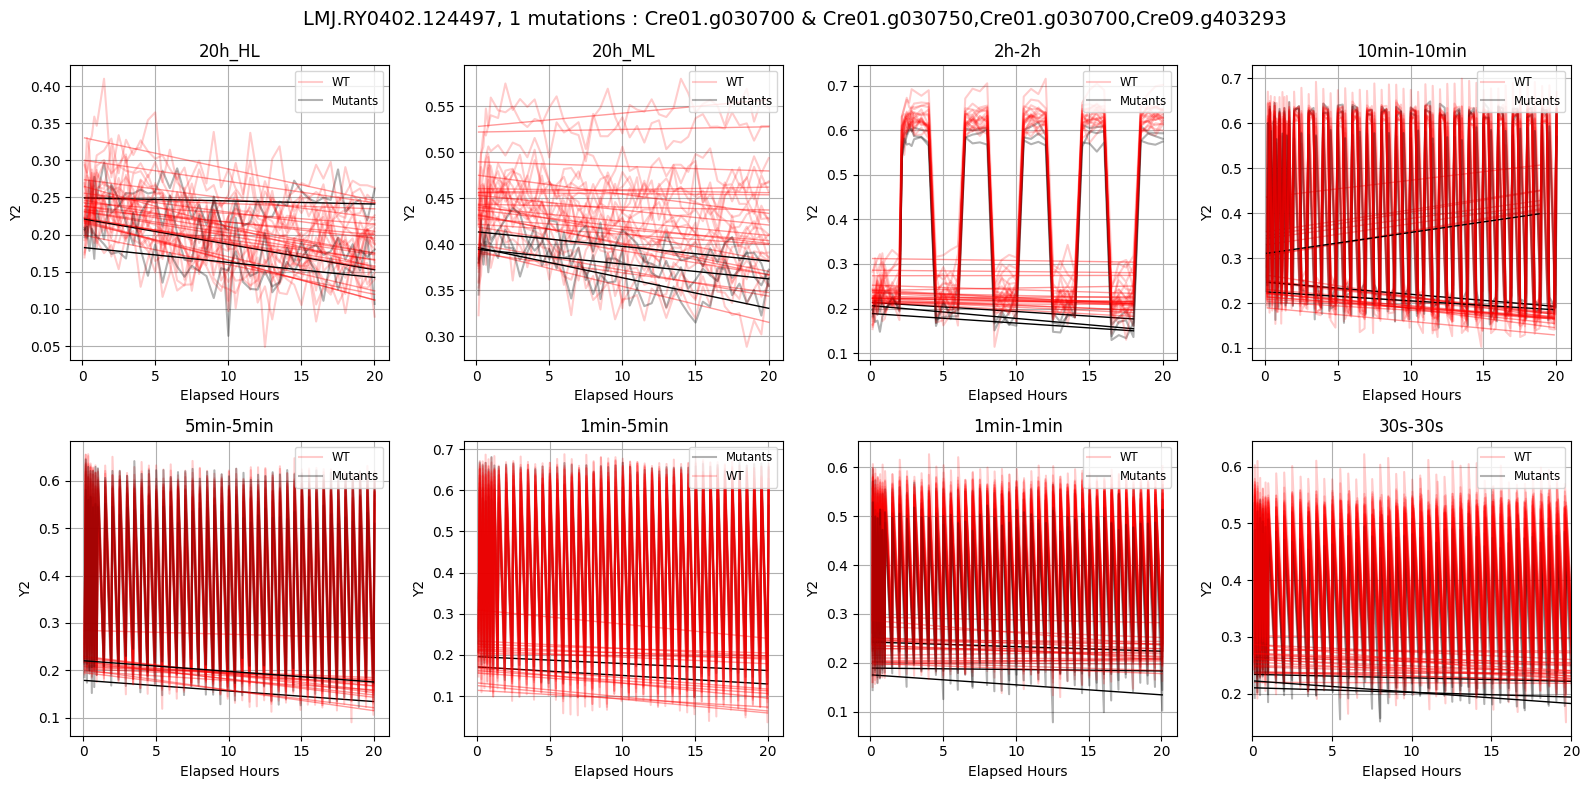

In [24]:
#data = pd.concat((plate1,filtered_data))
#data = filtered_data
from sklearn.linear_model import LinearRegression

data = pd.read_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/2025_5_phase2_light_status_slope.csv')
#data = data[data['plate'].astype(str).str.startswith('31v3')]
mutant = 'LMJ.RY0402.124497'
genes = data[data['mutant_ID']==mutant]['mutated_genes'].unique()
print(genes)
for gene in genes : 
    gene_plates = data[data['mutated_genes'].str.contains(gene, na=False)]['plate'].unique()
    print(gene_plates)
    data = data[data['mutated_genes'].str.contains(f"{gene}|WT", na=False) & data['mutant_ID'].str.contains(f"{mutant}|WT", na=False) & data['plate'].isin(gene_plates)]
    #data = data[data['mutant_ID']=='LMJ.RY0402.097244']
    y2_columns = [col for col in data.columns if col.startswith('y2_') and col.split('_')[-1].isdigit() and 'std' not in col]
    time_columns = [col for col in data.columns if col.startswith('measurement_time_')]
    for col in time_columns:
        data[col] = pd.to_datetime(data[col],format='mixed')
    elapsed_hours = data[time_columns].apply(lambda row: (row - row.min()).dt.total_seconds() / 3600, axis=1)

    # for normalised data
    elapsed_hours = [col for col in data.columns if col.startswith('elapsed_hours_')]
    elapsed_hours = data[elapsed_hours]
    light_status_cols = [col for col in data.columns if col.startswith('light_status_')]

    # for raw slopes
    # elapsed_hours.columns = [f'elapsed_hours_{i}' for i in range(len(elapsed_hours.columns))]
    # data = pd.concat([data, elapsed_hours], axis=1)

    plates = data['plate'].unique()
    colors = plt.cm.tab20(np.linspace(0, 1, len(plates)))  
    plate_colors = {plate: color for plate, color in zip(plates, colors)}
    light_regimes = ['20h_HL', '20h_ML', '2h-2h', '10min-10min', '5min-5min', '1min-5min', '1min-1min', '30s-30s']

    #light_regimes = ['20h_HL','1min-1min','30s-30s']
    fig, axes = plt.subplots(2, 4, figsize=(16,8))  
    axes = axes.flatten()
    light_status_cols = [col for col in data.columns if col.startswith('light_status_')]


    # Assign colors
    mutant_ids = data[data['mutant_ID'] != 'WT']['mutant_ID'].unique()
    color_map = plt.cm.tab10(np.linspace(0, 1, len(mutant_ids)))
    mutant_colors = {mutant: color for mutant, color in zip(mutant_ids, color_map)}

    plotted_labels = set()
    for i, light in enumerate(light_regimes):
        c, w = 0, 0
        ax = axes[i]
        data_light = data[data['light_regime'] == light]

        for _, row in data_light.iterrows():
            y2_values = row[y2_columns].astype(float).values
            time_values = row[elapsed_hours.columns[1:]].astype(float).values
            light_status = row[light_status_cols[1:]].astype(str).values

            valid_mask = (~np.isnan(time_values)) & (~np.isnan(y2_values))
            time_values = time_values[valid_mask]
            y2_values = y2_values[valid_mask]
            light_status = light_status[valid_mask]

            # Base plot
            base_color = 'black' if row['mutant_ID'] != 'WT' else 'red'
            alpha = 0.3 if row['mutant_ID'] != 'WT' else 0.2
            label = 'Mutants' if (row['mutant_ID'] != 'WT' and w == 0) else ('WT' if c == 0 and row['mutant_ID'] == 'WT' else None)

            if row['mutant_ID'] != 'WT': w += (label is not None)
            else: c += (label is not None)
            ax.plot(time_values, y2_values, color=base_color, alpha=alpha, label=label)


            # Scatter points for light/dark phases
            # ax.scatter(time_values[light_status == 'light'], y2_values[light_status == 'light'], color='orange', s=10, alpha=0.6)
            # ax.scatter(time_values[light_status == 'dark'], y2_values[light_status == 'dark'], color='blue', s=10, alpha=0.6)

            # Regression lines
            #for condition, reg_color in zip(['light', 'dark'], ['orange', 'blue']):
            cond_mask = light_status == 'light'
            if cond_mask.sum() >= 2:
                x = time_values[cond_mask].reshape(-1, 1)
                y = y2_values[cond_mask]
                model = LinearRegression().fit(x, y)
                x_line = np.linspace(x.min(), x.max(), 100).reshape(-1, 1)
                y_line = model.predict(x_line)
                reg_alpha = 1 if row['mutant_ID'] != 'WT' else 0.4  # Higher alpha for mutants, lower for WT
                ax.plot(x_line, y_line, color=base_color, linewidth=1, alpha=reg_alpha)

        ax.set_title(f'{light}')
        ax.set_xlabel('Elapsed Hours')
        ax.set_ylabel('Y2')
        ax.grid(True)
        ax.legend(fontsize='small', loc='upper right')

    for j in range(len(light_regimes), len(axes)):
        fig.delaxes(axes[j])
    fig.suptitle(f"{mutant}, {len({', '.join(genes)})} mutations : {', '.join(genes)}", fontsize=14)
    plt.xlim(0,20)
    plt.tight_layout()
    plt.show()

In [21]:
data = pd.read_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/2025_5_phase2.csv')
data = data[(data['mutant_ID']=='LMJ.RY0402.137230')]
data['light_regime'].unique()

/tmp/ipykernel_668686/1937955502.py:1: DtypeWarning: Columns (462,463) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/2025_5_phase2.csv')


array(['10min-10min', '1min-5min', '5min-5min'], dtype=object)